**Implement an End to End CNN Model for Image Classification Task.**
# Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon
using TensorFlow and Keras.


# Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class. You are expected to write a code:
*   Get the list of class directories from the train folder.
*   Select one image randomly from each class.
*   Display the images in a grid format with two rows using matplotlib.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report

In [6]:
# dataset path
train_dir = "/content/drive/MyDrive/DeepLearning/FruitinAmazon/train"

# Get class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
classes = sorted(classes)

print("Classes found:", classes)

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
# Select one random image from each class
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_list = os.listdir(class_path)

    if len(img_list) == 0:
        continue

    img_name = random.choice(img_list)
    img_path = os.path.join(class_path, img_name)

    images.append(img_path)
    labels.append(cls)

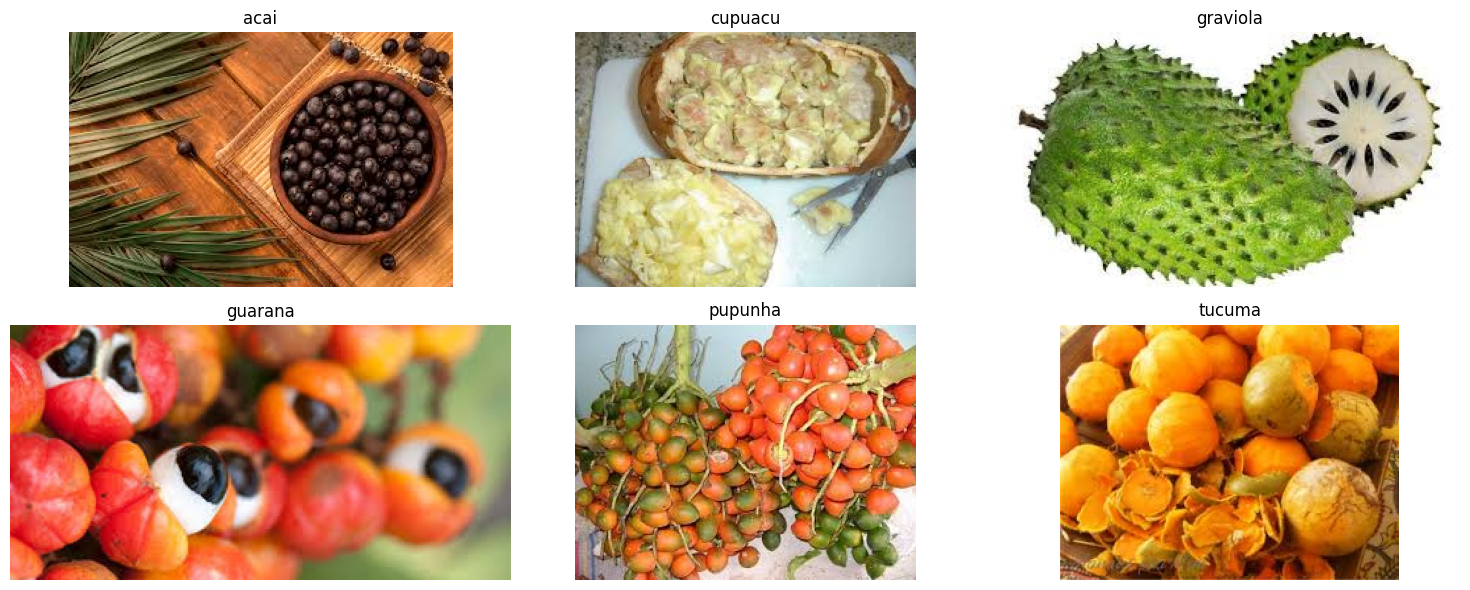

In [8]:
# Display images using Pillow
num_images = len(images)
cols = (num_images + 1) // 2  # 2 rows

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(images):
    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

2. Check for Corrupted Image: Write a script that verifies whether the image in the train directory are valid. If any corrupted images are found, the script must remove the image from the directory and print the message which image have been removed, if none found print ”No Corrupted Images Found.”

In [13]:
corrupted_images = []

# Get class folders
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]

# Loop through each class folder
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()  # Check if image is valid

        except (IOError, UnidentifiedImageError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final Output
if not corrupted_images:
    print("\nNo corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")


No corrupted images found.


# Task 2: Loading and Preprocessing Image Data in keras:
In this section, we will load and preprocess image data from a directory using the image dataset from directory function in Keras.

In [25]:
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:

**Convolutional Architecture:**

Convolutional Architecture:
• Convolutional Layer 1:
– Filter Size (F): (3,3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 1: Max pooling
– Filter Size (F): (2,2)
– Stride (s): 2
• Convolutional Layer 2:
– Filter Size (F): (3,3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling
– Filter Size (F): (2,2)
– Stride (s): 2

In [26]:
# Build ONLY the convolutional part
conv_model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(
        filters=32,              # Number of filters (k = 32)
        kernel_size=(3,3),       # Filter size (3x3)
        strides=1,               # Stride (s = 1)
        padding='same',          # Padding (P = same)
        input_shape=(128,128,3)  # Input shape (required for first layer)
    ),

    # Activation Layer (ReLU)
    layers.Activation('relu'),

    # Pooling Layer 1 (MaxPooling)
    layers.MaxPooling2D(
        pool_size=(2,2),         # Filter size (2x2)
        strides=2                # Stride (s = 2)
    ),

    # Convolutional Layer 2
    layers.Conv2D(
        filters=32,
        kernel_size=(3,3),
        strides=1,
        padding='same'
    ),

    # Activation Layer (ReLU)
    layers.Activation('relu'),

    # Pooling Layer 2 (MaxPooling)
    layers.MaxPooling2D(
        pool_size=(2,2),
        strides=2
    )

])

Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer - 2:
– Number of Neurons: 64
– Number of Neurons: 128
• Output Layer:
– Number of Neurons: num classes (number of output classes)

In [29]:
temp_ds = tf.keras.preprocessing.image_dataset_from_directory(train_dir)

class_names = temp_ds.class_names
num_classes = len(class_names)

Found 90 files belonging to 6 classes.


In [30]:
# Build full model by extending convolutional model
model = models.Sequential([

    # Include convolutional base
    conv_model,

    # Flatten Layer
    layers.Flatten(),

    # Hidden Layer 1
    layers.Dense(
        64,
        activation='relu'
    ),

    # Hidden Layer 2
    layers.Dense(
        128,
        activation='relu'
    ),

    # Output Layer
    layers.Dense(
        num_classes,
        activation='softmax'
    )

])

# Task 4: Compile the Model

Model Compilation
*   Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy), and evaluation metric (e.g., accuracy).

In [31]:
# Compile the CNN model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train the Model

Model Training
* Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
* Use val ds for validation.
* Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-ing overfitting.

In [33]:
# Callback 1: Save best model based on validation accuracy
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Callback 2: Stop training early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [34]:
# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.1644 - loss: 1.9516
Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 645ms/step - accuracy: 0.1806 - loss: 2.0198 - val_accuracy: 0.0556 - val_loss: 1.7866
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.2396 - loss: 1.6832
Epoch 2: val_accuracy improved from 0.05556 to 0.83333, saving model to /content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.2500 - loss: 1.6787 - val_accuracy: 0.8333 - val_loss: 1.2439
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.3709 - loss: 1.5533
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 709ms/step - accuracy: 0.3472 - loss: 1.5438 - val_accuracy: 0.8333 - val_loss: 1.2554
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.5284 - loss: 1.2873
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 708ms/step - accuracy: 0.5694 - loss: 1.2601 - val_accuracy: 0.2778 - val_loss: 1.4879
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5133 - loss: 1.1021
Epoch 5: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 598ms/step - accuracy: 0.5556 - loss: 1.0877 - val_accuracy: 0.8333 - val_loss: 0.8189
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━


Epoch 12: finished saving model to /content/drive/MyDrive/DeepLearning/FruitinAmazon/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 941ms/step - accuracy: 1.0000 - loss: 0.1012 - val_accuracy: 0.8889 - val_loss: 0.5579
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 1.0000 - loss: 0.0566
Epoch 13: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 1.0000 - loss: 0.0542 - val_accuracy: 0.8333 - val_loss: 0.4938
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 1.0000 - loss: 0.0309
Epoch 14: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 563ms/step - accuracy: 1.0000 - loss: 0.0322 - val_accuracy: 0.7778 - val_loss: 0.5007
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 1.0000 - loss: 0.0234
Epoch 15: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 470ms/step - accuracy: 1.0000 - loss: 0.0223 - val_accuracy: 0.8333 - val_loss: 0.4697
Epoch 16/250
3/3 ━━━━━━━━━

# Task 5: Evaluate the Model
Model Evaluation
* After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [35]:
# Load test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/DeepLearning/FruitinAmazon/test",
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)
# Normalize test data
test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 30 files belonging to 6 classes.


In [36]:
# Evaluate model on test dataset
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6333 - loss: 1.0375
Test Loss: 1.0375484228134155
Test Accuracy: 0.6333333253860474


# Task 6: Save and Load the Model
Model Saving and Loading
* Save the trained model to an .h5 file using model.save().
* Load the saved model and re-evaluate its performance on the test set.

In [37]:
# Save trained model to .h5 file
model.save("/content/drive/MyDrive/DeepLearning/FruitinAmazon/final_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [39]:
# Load saved model
loaded_model = load_model("/content/drive/MyDrive/DeepLearning/FruitinAmazon/final_model.h5")
print("Model loaded successfully!")

Model loaded successfully!


In [40]:
# Evaluate loaded model on test data
loss, accuracy = loaded_model.evaluate(test_ds)

print("Loaded Model Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.6333 - loss: 1.0375
Loaded Model Accuracy: 0.6333333253860474


# Task 7: Predictions and Classification Report
Making Predictions
* Use model.predict() to make predictions on test images.
* Convert the model’s predicted probabilities to digit labels using np.argmax().
* Also use from sklearn.metrics import classification report to report the Classification Report of your Model Performance.

In [42]:
# Get predictions (probabilities)
predictions = loaded_model.predict(test_ds)

# Convert probabilities → class labels
y_pred = np.argmax(predictions, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


In [43]:
# Extract true labels from dataset

y_true = []

for images, labels in test_ds:
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

In [45]:
# Use class names from earlier
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.71      1.00      0.83         5
     guarana       0.67      0.40      0.50         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.63        30
   macro avg       0.67      0.63      0.62        30
weighted avg       0.67      0.63      0.62        30

